# Time Domain vs Frequency Domain

**Learning Goals**
- Understand what the time domain and the frequency domain are
- Understand what an LTI system is
- Understand the Laplace transform and why it is useful
- Understand what a transfer function is
- Understand what poles are and what they tell us about system behavior
- See the connection between time-domain response and pole locations


## Relevant lecture video

In [1]:
from IPython.display import HTML

HTML('<iframe width="560" height="315" src="https://echo360.org/media/040e1211-85df-4a5b-9f6b-b7ee832944ac/public?autoplay=false&automute=false&currentMediaId=8ab5262e-3db6-4b48-9c09-d95c0fc7670b" frameborder="0" allowfullscreen></iframe>')

/home/matvei/JupyterBasedControlEngineeringTextbook/venv/lib/python3.12/site-packages/IPython/core/display.py:447: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


---

## What is the time domain?

The **time domain** describes how a signal or system output changes over time. We write it as $x(t)$, where $t$ is time.

In the introduction, we plotted the block's position $x(t)$ against time. That plot was a time-domain view of the system.

---

## What is an LTI system?

An **LTI system** (Linear Time-Invariant system) satisfies two properties:

- **Linearity**: If input $x_1(t)$ produces output $y_1(t)$ and input $x_2(t)$ produces $y_2(t)$, then input $a x_1(t) + b x_2(t)$ produces output $a y_1(t) + b y_2(t)$.
- **Time invariance**: If input $x(t)$ produces output $y(t)$, then input $x(t - T)$ produces output $y(t - T)$.

Most physical systems we study in control engineering (including the block on ice) are approximately LTI when operating near a setpoint.

---

## What is the frequency domain?

The **frequency domain** describes a signal in terms of the frequencies it contains. Instead of showing how $x$ changes over time, we show how much of each frequency is present.

**Fourier's theorem** states that any periodic signal can be written as a sum of sine waves:

$$x(t) = A_0 + \sum_{n=1}^{\infty} A_n \sin(n \omega_0 t + \phi_n)$$

The plot of $A_n$ versus frequency $\omega$ is the **frequency spectrum** of the signal.

The interactive tool below lets you build a signal from sine waves and see both its time-domain waveform and its frequency spectrum side by side.

In [1]:
%pip install -q ipywidgets

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
import ipywidgets as widgets
from IPython.display import display, clear_output, Audio, HTML
from scipy.fft import fft, fftfreq

print("Libraries loaded.")

Libraries loaded.


## Sum of Sines Synthesizer

Build a sound wave by adding up to three sine components. Adjust each frequency, amplitude, and phase, then click **Run** to see the waveform, its frequency spectrum, and hear the result.

In [3]:
def sum_of_sines_synth(f1=220, a1=0.5, p1=0, f2=440, a2=0.3, p2=0, f3=880, a3=0.2, p3=0):
    fs = 44100
    duration = 1.0
    t = np.linspace(0, duration, int(fs * duration), endpoint=False)

    freqs = [f1, f2, f3]
    amps = [a1, a2, a3]
    phases = [p1, p2, p3]

    signal = np.zeros_like(t)
    for f, a, p in zip(freqs, amps, phases):
        signal += a * np.sin(2 * np.pi * f * t + p)

    max_amp = np.max(np.abs(signal))
    if max_amp > 0:
        signal = signal / max_amp * 0.9

    fig = plt.figure(figsize=(12, 8))
    gs = fig.add_gridspec(2, 2, height_ratios=[1, 1])

    ax1 = fig.add_subplot(gs[0, :])
    t_show = t[:2000]
    sig_show = signal[:2000]
    ax1.plot(t_show * 1000, sig_show, 'b-', linewidth=1.5)
    ax1.axhline(0, color='k', alpha=0.2)
    ax1.set(xlabel='Time (ms)', ylabel='Amplitude', title='Time Domain Waveform')
    ax1.grid(alpha=0.3)

    ax2 = fig.add_subplot(gs[1, 0])
    N = len(signal)
    Y = fft(signal)
    freq = fftfreq(N, 1 / fs)
    pos = freq >= 0
    ax2.plot(freq[pos], np.abs(Y)[pos] / N * 2, 'r-', linewidth=1.5)
    ax2.set(xlabel='Frequency (Hz)', ylabel='Magnitude', title='Frequency Spectrum',
            xlim=(0, max(2000, max(freqs) * 1.5)))
    ax2.grid(alpha=0.3)

    ax3 = fig.add_subplot(gs[1, 1])
    parts = []
    for i, (f, a) in enumerate(zip(freqs, amps)):
        if a > 0.01:
            parts.append(f'Component {i+1}: $A_{i+1} = {a:.2f}$, $f_{i+1} = {f:.0f}$ Hz')
    ax3.text(0.1, 0.5, '\n'.join(parts), fontsize=13, verticalalignment='center')
    ax3.set_title('Active Components')
    ax3.axis('off')

    fig.tight_layout()
    plt.show()

    label = ' + '.join(
        f'{a:.2f} sin(2π × {f:.0f}t)' for f, a in zip(freqs, amps) if a > 0.01
    ) or '(silence)'
    print(f'Signal: {label}')
    display(Audio(signal, rate=fs))

f1_s = widgets.FloatSlider(min=55, max=1760, step=1, value=220, description='$f_1$ (Hz):', style={'description_width': 'initial'})
a1_s = widgets.FloatSlider(min=0, max=1, step=0.05, value=0.5, description='$A_1$:', style={'description_width': 'initial'})
p1_s = widgets.FloatSlider(min=0, max=6.28, step=0.1, value=0, description='$\\varphi_1$:', style={'description_width': 'initial'})
f2_s = widgets.FloatSlider(min=55, max=1760, step=1, value=440, description='$f_2$ (Hz):', style={'description_width': 'initial'})
a2_s = widgets.FloatSlider(min=0, max=1, step=0.05, value=0.3, description='$A_2$:', style={'description_width': 'initial'})
p2_s = widgets.FloatSlider(min=0, max=6.28, step=0.1, value=0, description='$\\varphi_2$:', style={'description_width': 'initial'})
f3_s = widgets.FloatSlider(min=55, max=1760, step=1, value=880, description='$f_3$ (Hz):', style={'description_width': 'initial'})
a3_s = widgets.FloatSlider(min=0, max=1, step=0.05, value=0.2, description='$A_3$:', style={'description_width': 'initial'})
p3_s = widgets.FloatSlider(min=0, max=6.28, step=0.1, value=0, description='$\\varphi_3$:', style={'description_width': 'initial'})

run_btn = widgets.Button(description='Run', button_style='primary')
out = widgets.Output()

def on_run(b):
    with out:
        clear_output(wait=True)
        sum_of_sines_synth(f1_s.value, a1_s.value, p1_s.value,
                           f2_s.value, a2_s.value, p2_s.value,
                           f3_s.value, a3_s.value, p3_s.value)

run_btn.on_click(on_run)
display(widgets.VBox([
    widgets.HBox([f1_s, a1_s, p1_s]),
    widgets.HBox([f2_s, a2_s, p2_s]),
    widgets.HBox([f3_s, a3_s, p3_s]),
    run_btn, out
]))
print("Adjust the sliders, then click Run to see and hear the result.")

Adjust the sliders, then click Run to see and hear the result.


---

## What is the Laplace transform?

The **Laplace transform** converts a function of time $f(t)$ into a function of a complex variable $F(s)$:

$$\mathcal{L}\{f\}(s) = \int_0^\infty f(t) e^{-st} dt$$

where $s = \sigma + j\omega$ is a complex number.

Why do we use it? Because it turns **differential equations into algebra**. In the time domain, the block on ice follows $m \ddot x + b \dot x = F$. In the $s$-domain, differentiation becomes multiplication by $s$:

$$m s^2 X(s) + b s X(s) = F(s)$$

The boxes below compute the Laplace transforms of common signals automatically.

### Laplace transforms of common signals

In [4]:
s, t = sp.symbols('s t', positive=True)
omega = sp.symbols('omega', positive=True)
alpha = sp.symbols('alpha', real=True)

f_sin = sp.sin(omega * t)
F_sin = sp.laplace_transform(f_sin, t, s)[0]
f_cos = sp.cos(omega * t)
F_cos = sp.laplace_transform(f_cos, t, s)[0]
f_exp = sp.exp(-alpha * t) * sp.sin(omega * t)
F_exp = sp.laplace_transform(f_exp, t, s)[0]

display(HTML(f'''
<b>Sine:</b> $\\mathcal{{L}}\{{{sp.latex(f_sin)}\}} = {sp.latex(F_sin)}$<br>
<b>Cosine:</b> $\\mathcal{{L}}\{{{sp.latex(f_cos)}\}} = {sp.latex(F_cos)}$<br>
<b>Damped sine:</b> $\\mathcal{{L}}\{{{sp.latex(f_exp)}\}} = {sp.latex(F_exp)}$
'''))

print("\nThe poles of these transforms live in the s-plane (below).")

<string>:13: SyntaxWarning: invalid escape sequence '\{'
<string>:13: SyntaxWarning: invalid escape sequence '\}'
<string>:14: SyntaxWarning: invalid escape sequence '\{'
<string>:14: SyntaxWarning: invalid escape sequence '\}'
<string>:15: SyntaxWarning: invalid escape sequence '\{'
<string>:15: SyntaxWarning: invalid escape sequence '\}'
<>:13: SyntaxWarning: invalid escape sequence '\{'
<>:13: SyntaxWarning: invalid escape sequence '\}'
<>:14: SyntaxWarning: invalid escape sequence '\{'
<>:14: SyntaxWarning: invalid escape sequence '\}'
<>:15: SyntaxWarning: invalid escape sequence '\{'
<>:15: SyntaxWarning: invalid escape sequence '\}'
<string>:13: SyntaxWarning: invalid escape sequence '\{'
<string>:13: SyntaxWarning: invalid escape sequence '\}'
<string>:14: SyntaxWarning: invalid escape sequence '\{'
<string>:14: SyntaxWarning: invalid escape sequence '\}'
<string>:15: SyntaxWarning: invalid escape sequence '\{'
<string>:15: SyntaxWarning: invalid escape sequence '\}'
<>:13: Syn


The poles of these transforms live in the s-plane (below).


---

## What is a transfer function?

A **transfer function** $G(s)$ is the ratio of the Laplace transform of the output to the Laplace transform of the input, assuming zero initial conditions:

$$G(s) = \frac{Y(s)}{U(s)}$$

For the block on ice, the equation $m \ddot x + b \dot x = F$ becomes $m s^2 X(s) + b s X(s) = F(s)$ in the $s$-domain. Solving for the transfer function from force $F$ to position $X$:

$$G(s) = \frac{X(s)}{F(s)} = \frac{1}{s(m s + b)}$$

The transfer function completely describes the input-output behavior of an LTI system. Once we know $G(s)$, we know how the system will respond to any input.

---

## What are poles?

The **poles** of a transfer function are the roots of the denominator. For $G(s) = 1 / (s(m s + b))$, the poles are $s = 0$ and $s = -b/m$.

Pole locations in the $s$-plane tell us how the system will behave:
- Poles on the imaginary axis ($s = \pm j\omega$) produce **sustained oscillation**.
- Poles in the left half-plane ($\text{Re}(s) < 0$) produce **decaying (stable) response**.
- Poles in the right half-plane ($\text{Re}(s) > 0$) produce **growing (unstable) response**.

The $s$-plane plots below show these three cases.

### s-Plane Pole Map

Poles of sin(ωt): ±jω (on imaginary axis - sustained oscillation)


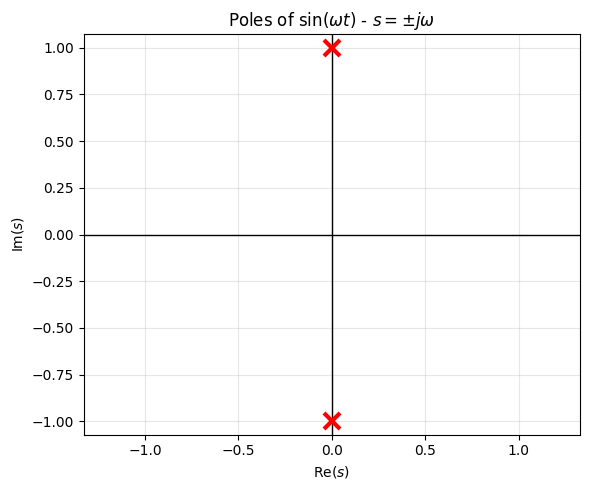

Poles of e^{-αt} sin(ωt): −α ± jω (left half-plane - decaying)


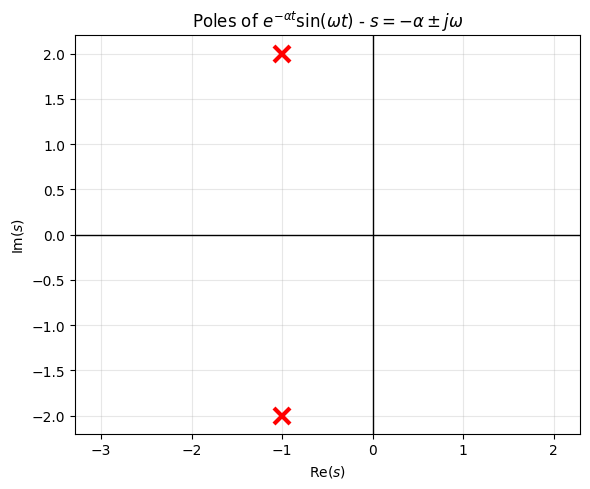

A right half-plane pole means instability.


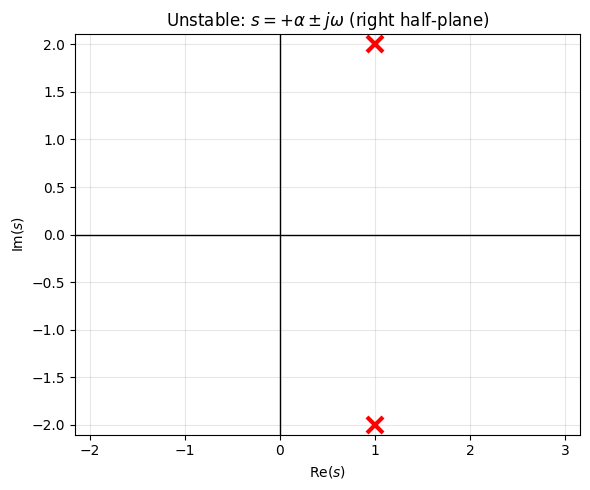

In [5]:
def plot_splane(poles, title='s-Plane'):
    fig, ax = plt.subplots(figsize=(6, 5))
    limit = max(np.ceil(max(abs(np.real(poles)) + 1)), np.ceil(max(abs(np.imag(poles)) + 1)), 3)
    ax.axhline(0, color='k', linewidth=1)
    ax.axvline(0, color='k', linewidth=1)
    ax.set_xlim(-limit, limit)
    ax.set_ylim(-limit, limit)
    ax.set(xlabel='Re($s$)', ylabel='Im($s$)', title=title)
    ax.grid(alpha=0.3)
    for p in poles:
        ax.plot(p.real, p.imag, 'rx', markersize=12, markeredgewidth=3)
    ax.axis('equal')
    fig.tight_layout()
    plt.show()

print('Poles of sin(ωt): ±jω (on imaginary axis - sustained oscillation)')
plot_splane([complex(0, 1), complex(0, -1)], 'Poles of $\\sin(\\omega t)$ - $s = \\pm j\\omega$')

print('Poles of e^{-αt} sin(ωt): −α ± jω (left half-plane - decaying)')
plot_splane([complex(-1, 2), complex(-1, -2)], 'Poles of $e^{-\\alpha t}\\sin(\\omega t)$ - $s = -\\alpha \\pm j\\omega$')

print('A right half-plane pole means instability.')
plot_splane([complex(1, 2), complex(1, -2)], 'Unstable: $s = +\\alpha \\pm j\\omega$ (right half-plane)')

---

## Interactive s-Plane Explorer

Adjust a sine wave's frequency $\omega$ and damping $\alpha$. Watch the poles move in the $s$-plane and see how the time-domain response changes.

In [6]:
def explore_splane(omega=440, alpha=0):
    s_sym = sp.symbols('s')
    tt = sp.symbols('t', positive=True)

    if alpha == 0:
        time_expr = sp.sin(omega * tt)
        lap_expr = omega / (s_sym ** 2 + omega ** 2)
        poles = [complex(0, omega), complex(0, -omega)]
        label = f'sin({omega}t)'
    else:
        time_expr = sp.exp(-alpha * tt) * sp.sin(omega * tt)
        lap_expr = omega / ((s_sym + alpha) ** 2 + omega ** 2)
        poles = [complex(-alpha, omega), complex(-alpha, -omega)]
        label = f'e^({-alpha}t) sin({omega}t)'

    display(HTML(
        f'<b>Time domain:</b> $x(t) = {sp.latex(time_expr)}$<br>'
        f'<b>Laplace transform:</b> $X(s) = {sp.latex(lap_expr)}$<br>'
        f'<b>Poles:</b> $s = {sp.latex(poles[0])},\; {sp.latex(poles[1])}$'
    ))

    fig = plt.figure(figsize=(12, 5))
    gs = fig.add_gridspec(1, 2)

    ax1 = fig.add_subplot(gs[0])
    limit = max(omega * 1.5, alpha * 1.5, 100)
    ax1.axhline(0, color='k', linewidth=0.8)
    ax1.axvline(0, color='k', linewidth=0.8)
    ax1.set_xlim(-limit, limit)
    ax1.set_ylim(-limit, limit)
    ax1.set(xlabel='Re($s$)', ylabel='Im($s$)', title='s-Plane')
    ax1.grid(alpha=0.3)
    for p in poles:
        ax1.plot(p.real, p.imag, 'rx', markersize=12, markeredgewidth=3)
    ax1.axvspan(0, limit, alpha=0.08, color='r')
    ax1.axvspan(-limit, 0, alpha=0.08, color='g')
    ax1.text(-limit * 0.9, limit * 0.85, 'Stable', fontsize=11, color='g', fontweight='bold')
    ax1.text(limit * 0.05, limit * 0.85, 'Unstable', fontsize=11, color='r', fontweight='bold')
    ax1.axis('equal')

    ax2 = fig.add_subplot(gs[1])
    t_vals = np.linspace(0, 0.05, 1000)
    x_vals = np.exp(-alpha * t_vals) * np.sin(omega * t_vals)
    ax2.plot(t_vals * 1000, x_vals, 'b-', linewidth=1.5)
    ax2.axhline(0, color='k', alpha=0.2)
    ax2.set(xlabel='Time (ms)', ylabel='$x(t)$', title=f'Time Response: {label}')
    ax2.grid(alpha=0.3)

    fig.tight_layout()
    plt.show()

omega_s = widgets.FloatSlider(min=100, max=2000, step=10, value=440,
                              description='$\\omega$ (rad/s):', style={'description_width': 'initial'})
alpha_s = widgets.FloatSlider(min=0, max=500, step=5, value=0,
                              description='$\\alpha$ (damping):', style={'description_width': 'initial'})

run_btn2 = widgets.Button(description='Run', button_style='primary')
out2 = widgets.Output()

def on_run2(b):
    with out2:
        clear_output(wait=True)
        explore_splane(omega_s.value, alpha_s.value)

run_btn2.on_click(on_run2)
display(widgets.VBox([widgets.HBox([omega_s, alpha_s]), run_btn2, out2]))
print("Adjust frequency and damping, then click Run to see poles and response.")

<>:19: SyntaxWarning: invalid escape sequence '\;'
<>:19: SyntaxWarning: invalid escape sequence '\;'
/tmp/ipykernel_53731/3681987754.py:19: SyntaxWarning: invalid escape sequence '\;'
  f'<b>Poles:</b> $s = {sp.latex(poles[0])},\; {sp.latex(poles[1])}$'


Adjust frequency and damping, then click Run to see poles and response.


---

## Summary

- The **time domain** shows how a signal evolves: $x(t)$.
- The **frequency domain** shows the spectral content of a signal: $X(j\omega)$.
- An **LTI system** is linear and time-invariant, making it easy to analyze.
- The **Laplace transform** converts differential equations into algebraic equations.
- A **transfer function** $G(s) = Y(s)/U(s)$ describes an LTI system's input-output behavior.
- **Poles** are the roots of the denominator of $G(s)$. Their locations determine stability and response type:
  - Imaginary axis $\to$ sustained oscillation
  - Left half-plane $\to$ stable (decaying)
  - Right half-plane $\to$ unstable (growing)